# Preprocessing data

**Menyiapkan libary yang digunakan**

In [1]:
import pandas as pd
import string


import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report,confusion_matrix

**Membaca data**

In [2]:
data = pd.read_csv('tiktok_google_play_reviews.csv')
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,59a9deec-44e9-4d7c-9b14-2c4602a9bd40,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya Suka,5,0,NaN,2026-05-09 16:39:16,Hi! Thanks for taking the time to share your f...,2026-05-09 17:00:11
1,af9a54e7-404e-452d-bb30-ddb6ac60fd52,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tiktok bagus untuk hiburan,4,0,45.0.3,2026-05-09 11:57:39,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-09 12:20:11
2,12e76901-d460-4380-90fe-c79313fd6623,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,45.0.3,2026-05-09 00:33:33,Hi! Thanks for taking the time to share your f...,2026-05-09 01:00:11
3,d678afbe-95c2-4282-a02f-43c9c824e7c3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jelek,1,0,45.0.3,2026-05-08 23:41:09,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-05-09 00:00:13
4,42f7024b-f888-4ba9-a371-6473ed5df5a1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa tidak bisa mengakses kamera ya?,5,0,45.0.3,2026-05-08 20:20:22,NaN,NaN


**Menghitung jumlah nilai NULL**

In [3]:
data.isnull().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    4019
at                         0
replyContent            9686
repliedAt               9686
dtype: int64

**Mengubah semua huruf pada data komentar menjadi huruf kecil**

In [4]:
data['content'] = data['content'].fillna('').str.lower()

def remove_special_characters(text):
    return text.translate(str.maketrans('', '', string.punctuation))

data['content'] = data['content'].apply(remove_special_characters)

data['score'] = pd.to_numeric(data['score'], errors='coerce')
data['Sentiment'] = ''
data.loc[data['score'] >= 4, 'Sentiment'] = 'positive'
data.loc[data['score'] <= 2, 'Sentiment'] = 'negative'

**Menghapus karakter spesial pada data komentar**

# EDA (Exploratory Data Analysis)

**Contoh dari komentar positif sebagai berikut**

In [5]:
print("Positive comment example: \n\n")

positive_comments_selection = data[data['score'] >= 4]

num_comments_to_display = min(10, len(positive_comments_selection))

for i in range(num_comments_to_display):
    print(f"Komentar #{i+1}")
    positive_comment = positive_comments_selection['content'].iloc[i]
    print(positive_comment + "\n")

if num_comments_to_display < 10:
    print(f"Hanya {num_comments_to_display} komentar positif yang ditemukan.")

Positive comment example: 


Komentar #1
saya suka

Komentar #2
tiktok bagus untuk hiburan

Komentar #3
good

Komentar #4
kenapa tidak bisa mengakses kamera ya

Komentar #5
enak banget buat nonton vidio tapi ada iklanyadan juga bisa buat komunikasi dengan mudah

Komentar #6
🔥🔥

Komentar #7
sangat menghibur 🥰❤️

Komentar #8
tidak tertandingi tiktok

Komentar #9
aplikasi bagusgk nya baru nyoba

Komentar #10
senang



Dari 10 komentar positif diatas, dapat dilihat bahwa ciri-ciri dari komentar positif adalah menggunakan kata-kata yang memiliki kesan supportive, kagum, dan membela suatu pihak yang benar berdasarkan perspektif pengomentar.

**Contoh komentar negatif sebagai berikut**

In [6]:
print("Negative comment example: \n\n")

negative_comments_selection = data[data['score'] <= 2]

num_comments_to_display = min(10, len(negative_comments_selection))

for i in range(num_comments_to_display):
    print(f"Komentar #{i+1}")
    negative_comment = negative_comments_selection['content'].iloc[i]
    print(negative_comment + "\n")

if num_comments_to_display < 10:
    print(f"Hanya {num_comments_to_display} komentar negatif yang ditemukan.")

Negative comment example: 


Komentar #1
jelek

Komentar #2
gooood

Komentar #3
sangat tidak puas dengan tiktok saat ini banyak peraturan dan tidak memudahkan penjual

Komentar #4
halo tolong perbaiki velocity yah karena velocitynya jadi ngelag banget tolong perbaiki yah please

Komentar #5
kenapa selalu tidak merespon terus tiktok skrg

Komentar #6
bintang 1 dulu orang2 0followers bisa live

Komentar #7
selalu berhentitiktok tidak menanggapi

Komentar #8
memberikan visibilitas yang tidak jelas tiba tiba keluar notif visibilitas padahal tidak melakukan apa apa kena pelanggaran yang tidak jelas makin kesini apk tiktok makin tidak baik baik saja 

Komentar #9
saya sangat sedih karna tiktok akun saya tibatiba di hapus padahal tidak ada yang salah gimana sihh tiktok dan saya mau daftar akun baru tapi tidak bisa karna pengaturan tanggal lahir saya malah tidak memenuhi persyaratan padahal itu tanggal lahir saya

Komentar #10
asoonn



Dari 10 komentar diatas, dapat dilihat bahwa komentar negatif memiliki ciri-ciri keluhan yang dirasakan untuk meminta segera diperbaiki

**Visualisasi proporsi data positif dan data negatif**

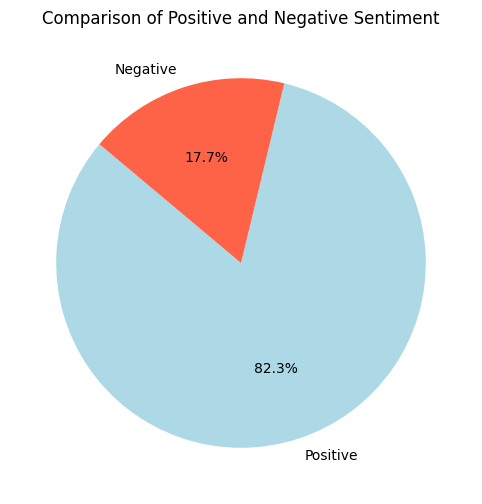

In [7]:
sentiment_for_plot = data['Sentiment'].value_counts()
sentiment_for_plot = sentiment_for_plot[sentiment_for_plot.index.isin(['positive', 'negative'])]

plt.figure(figsize=(8, 6))

labels = sentiment_for_plot.index.map(lambda x: x.capitalize())
colors_map = {'positive': 'lightblue', 'negative': 'tomato'}
plot_colors = [colors_map[label.lower()] for label in labels]

plt.pie(sentiment_for_plot, labels=labels, autopct='%1.1f%%', startangle=140, colors=plot_colors)
plt.title('Comparison of Positive and Negative Sentiment')
plt.show()

**Menghitung 10 kata terbanyak yang muncul pada komentar positif dan negatif**

In [ ]:
positive_com = data[data['Sentiment'] == 'positive']['content']
negative_com = data[data['Sentiment'] == 'negative']['content']

positive_word = Counter()
positive_com.apply(lambda x: positive_word.update(x.split()))

negative_word = Counter()
negative_com.apply(lambda x: negative_word.update(x.split()))

spam_positive = positive_word.most_common(10)
spam_negative = negative_word.most_common(10)

spam_positive_df = pd.DataFrame(spam_positive, columns=['Word','Frequency'])
spam_negative_df = pd.DataFrame(spam_negative, columns=['Word','Frequency'])

**Melakukan visualisasi kata yang paling sering muncul di komentar positif dan negatif**

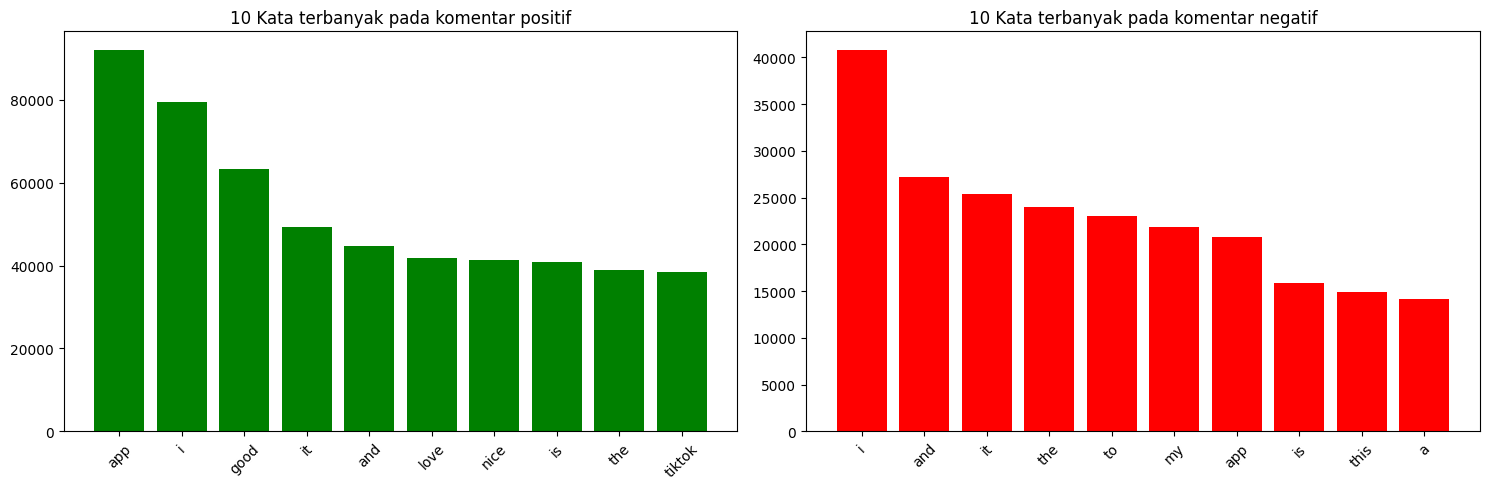

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(spam_positive_df['Word'], spam_positive_df['Frequency'], color='green')
plt.title('10 Kata terbanyak pada komentar positif')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(spam_negative_df['Word'], spam_negative_df['Frequency'], color='red')
plt.title('10 Kata terbanyak pada komentar negatif')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Melakukan visualisasi dengan Word cloud pada komentar positif**

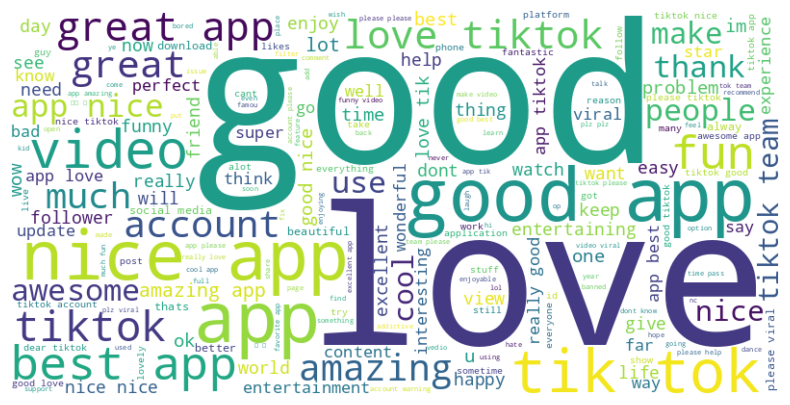

In [ ]:
positive_com_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_com))

plt.figure(figsize=(10, 5))
plt.imshow(positive_com_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Melakukan visualisasi dengan Word cloud pada komentar negatif**

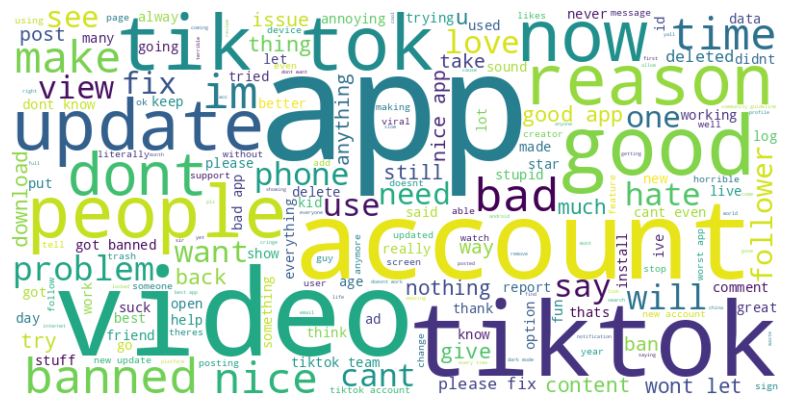

In [ ]:
#Negative Wordcloud
negative_com_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(negative_com))

plt.figure(figsize=(10, 5))
plt.imshow(negative_com_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Feature engineering

**Pembagian data train dan data testing**

In [ ]:
data_cleaned = data.dropna(subset=['Sentiment']).copy()

X = data_cleaned['content']
y = data_cleaned['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)

**Pembobotan dengan TF-IDF**

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('TF-IDF train shape:', X_train_tfidf.shape)
print('TF-IDF test shape:', X_test_tfidf.shape)
print('Jumlah fitur TF-IDF:', len(vectorizer.get_feature_names_out()))

         00  000  0000  00000  000000  0000000  00000000  000000000  \
0       0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
1       0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
2       0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
3       0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
4       0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
...     ...  ...   ...    ...     ...      ...       ...        ...   
441662  0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
441663  0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
441664  0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
441665  0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   
441666  0.0  0.0   0.0    0.0     0.0      0.0       0.0        0.0   

        00000000000  0000000000000000  ...  𝟐𝟎𝟐𝟎  𝟐𝟒𝟕  𝟐𝟔𝟕  𝟑𝟎𝟎  𝟕𝟕𝟑𝟗   𝟙𝕜  \
0               0.0               0.0  ...   0.0  0.0  0.0  0.0   0.0

**Pembobotan TF-IDF pada data training dan data testing**

In [ ]:
# Dataset sudah dimuat dan diproses sebelumnya.
# Tidak perlu memuat ulang dataset di sini.
pass

C:\Users\HP\AppData\Local\Temp\ipykernel_9988\700028910.py:7: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('tiktok_google_play_reviews.csv')


# Modeling

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print('Jumlah data training:', X_train_tfidf.shape[0])
print('Akurasi model = ', accuracy_score(y_test, y_pred))
print('Recall model = ', recall_score(y_test, y_pred, pos_label='positive'))
print('Precision model = ', precision_score(y_test, y_pred, pos_label='positive'))

C:\Users\HP\AppData\Local\Temp\ipykernel_9988\288588612.py:10: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('tiktok_google_play_reviews.csv')
C:\Users\HP\AppData\Local\Temp\ipykernel_9988\288588612.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'positive' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data['score'] >= 4, 'Sentiment'] = 'positive'


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\288588612.py:10: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('tiktok_google_play_reviews.csv')
C:\Users\HP\AppData\Local\Temp\ipykernel_9988\288588612.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'positive' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data['score'] >= 4, 'Sentiment'] = 'positive'


Jumlah data yang digunakan: 38421
Akurasi model =  0.8770331815224464
Recall model =  0.9774612615432775
Precision model =  0.886318478569401


# Evaluation

**Matrix confusion**

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_mtrx = confusion_matrix(y_pred, y_test)

print(confusion_mtrx)

[[ 495  144]
 [ 801 6245]]


**Laporan evaluasi**

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

    negative       0.77      0.38      0.51      1296
    positive       0.89      0.98      0.93      6389

    accuracy                           0.88      7685
   macro avg       0.83      0.68      0.72      7685
weighted avg       0.87      0.88      0.86      7685



Model yang dibuat mendapatkan:
*   nilai akurasi sebesar 0.88
*   nilai presisi untuk data negatif = 0.77
*   nilai presisi untuk data positif = 0.89
*   nilai recall untuk data negatif = 0.38
*   nilai recall untuk data positif = 0.98